# Introduction to xarray
### Documentation: https://docs.xarray.dev/en/stable/user-guide/index.html

Most of the oceanography data files are presented under a netCDF format.
netCDF is a binary format designed to store multi-dimensional gridded data. It contains:

- **Multi dimensional arrays**. e.g. Temperature (time, depth, latitude, longitude)
- **Metadata** (attributes) describing the data information (source, units, full name, relation to other data etc...)

In python, this kind of file is handled with **xarray**

In [5]:
import xarray as xr
import warnings
warnings.filterwarnings('ignore')
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import cartopy.crs as ccrs
import cartopy.feature   as cfeature
import matplotlib.dates  as mdates

# First data set 
## Mean daily sea surface temerature fields (SST)
- between September 1981 and August 2024
-  at 0.25° resolution.

The finial data, compiled in the context of a NOAA program, are obtained by interpolating and extrapolating SST observations from satellite and in-situe sources.

### Load data

The open_dataset routine creates a Dataset object, and loads the content of NetCDF file, including metadata, in this strucure.

In [6]:
data = xr.open_dataset('Datasets/SST_golfe_guinee_Tc.nc')
data

<xarray.Dataset> Size: 369MB
Dimensions:       (time: 15639, bnds: 2, lon: 92, lat: 64)
Coordinates:
  * time          (time) datetime64[ns] 125kB 1981-09-01 ... 2024-08-06
  * lon           (lon) float32 368B -7.875 -7.625 -7.375 ... 14.38 14.62 14.88
  * lat           (lat) float32 256B -6.875 -6.625 -6.375 ... 8.375 8.625 8.875
Dimensions without coordinates: bnds
Data variables:
    time_bnds     (time, bnds) object 250kB ...
    lon_bnds      (lon, bnds) float32 736B ...
    lat_bnds      (lat, bnds) float32 512B ...
    analysed_sst  (time, lat, lon) float32 368MB ...
Attributes: (12/49)
    CDI:                        Climate Data Interface version 2.4.0 (https:/...
    Conventions:                CF-1.6,ACDD-1.3
    source:                     AVHRR_Pathfinder-NODC-L3C-v5.1,ICOADS_SHIP-NC...
    institution:                NCEI
    product_version:            Version 2.0
    spatial_resolution:         0.25 degree
    ...                         ...
    standard_name_vocabulary:   CF Standard Name Table v29
    summary:                    NOAA's 1/4-degree Daily Optimum Interpolation...
    time_coverage_start:        19810901T000000Z
    time_coverage_end:          19810902T000000Z
    uuid:                       39832cc3-d409-438a-820e-2bb1b38ebca8
    CDO:                        Climate Data Operators version 2.4.0 (https:/...

We can rename the variables, here analysed_sst to sst

In [7]:
data= data.rename({'analysed_sst': 'sst'})

# We can also rename attributes.
data['sst'].attrs['standard_name'] = 'sea_surface_temperature'
data['sst'].attrs['long_name'] = 'analysed sea surface temperature'
data['sst'].attrs['units'] = 'C°'
data

<xarray.Dataset> Size: 369MB
Dimensions:    (time: 15639, bnds: 2, lon: 92, lat: 64)
Coordinates:
  * time       (time) datetime64[ns] 125kB 1981-09-01 1981-09-02 ... 2024-08-06
  * lon        (lon) float32 368B -7.875 -7.625 -7.375 ... 14.38 14.62 14.88
  * lat        (lat) float32 256B -6.875 -6.625 -6.375 ... 8.375 8.625 8.875
Dimensions without coordinates: bnds
Data variables:
    time_bnds  (time, bnds) object 250kB ...
    lon_bnds   (lon, bnds) float32 736B ...
    lat_bnds   (lat, bnds) float32 512B ...
    sst        (time, lat, lon) float32 368MB ...
Attributes: (12/49)
    CDI:                        Climate Data Interface version 2.4.0 (https:/...
    Conventions:                CF-1.6,ACDD-1.3
    source:                     AVHRR_Pathfinder-NODC-L3C-v5.1,ICOADS_SHIP-NC...
    institution:                NCEI
    product_version:            Version 2.0
    spatial_resolution:         0.25 degree
    ...                         ...
    standard_name_vocabulary:   CF Standard Name Table v29
    summary:                    NOAA's 1/4-degree Daily Optimum Interpolation...
    time_coverage_start:        19810901T000000Z
    time_coverage_end:          19810902T000000Z
    uuid:                       39832cc3-d409-438a-820e-2bb1b38ebca8
    CDO:                        Climate Data Operators version 2.4.0 (https:/...

**Dimensions** lists the differen array axes used by the tables stored in the NetCDF file. The size of the dimensions is written next to their names. 

**Coordinates** are the label/values associated with thoses axes. 

**Data variables** are one of several xarray.DataArray objects. These objects are labelled and multi-dimensional tables which can also contain metadata (attrivbutes. sont un ou plusieurs objets xarray.DataArray. Ces objects sont des tableaux étiquettés et multi-dimensionels qui peuvent aussi contenir des métadonnées (Attributes)


### Select and plot a quantity
The DataArray contains a SST time series, in a given (lat,lon) space. 

**.sel()** allows to select a given time value to plot

We can also use **.isel()**, if we want to give an index instead of a coordinate value

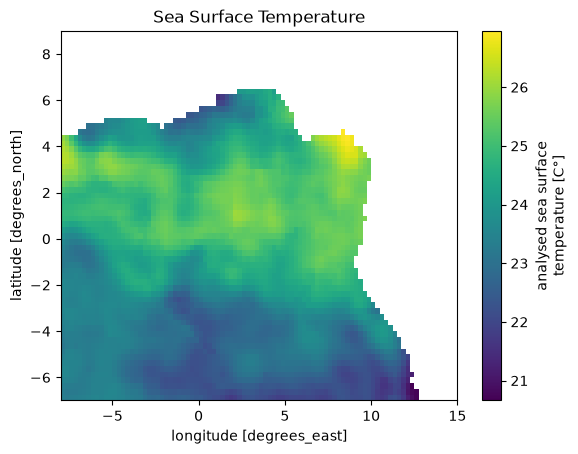

In [11]:
data.sst.sel(time='1981-09-01').plot(
    x='lon', 
    y='lat', 
    cmap='viridis'
)
plt.title('Sea Surface Temperature')
plt.show()
print('')

# Same plot, using .isel() insteand of .sel()
# data.sst.isel(time=0).plot(
#     x='lon', 
#     y='lat', 
#     cmap='viridis' 
# )
# plt.title('Sea Surface Temperature')
# plt.show()

## Means

### Climatology means
By computing the average temperature for a given month, agregated over all the years of observations, we can retrieve the temperature evolution over an average year.


Text(0.5, 1.03, 'Annual mean temperature cycle(°C)')

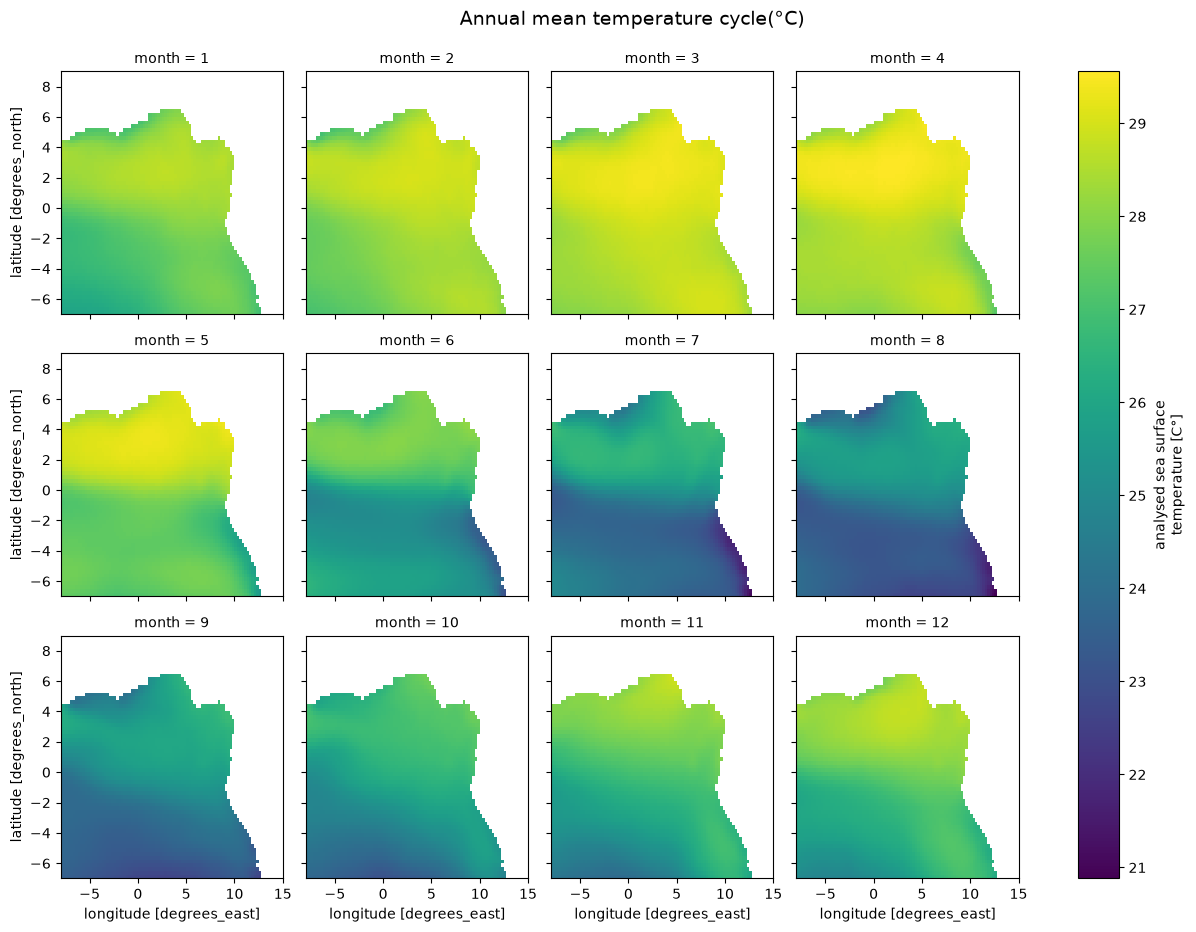

In [12]:
month = data.groupby('time.month').mean()
month.sst.plot(col='month',col_wrap=4)
# Set title above the top row with extra padding
plt.suptitle('Annual mean temperature cycle(°C)',y=1.03, fontsize=14)

### Mean temperature over the whole time series

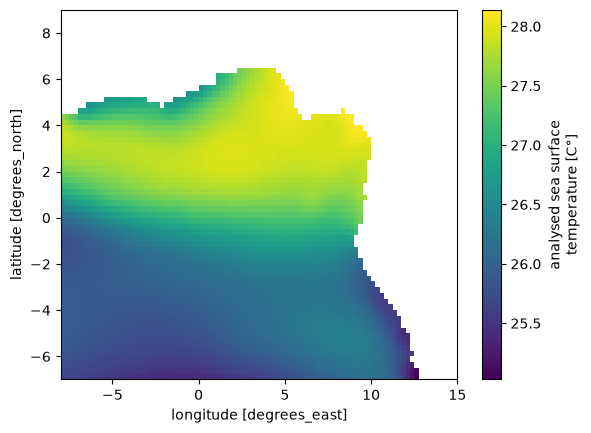

In [14]:
data.sst.mean(dim='time').plot(x='lon', y='lat')

### Spatial means

Temperature time series averaging over latitudes and longitudes

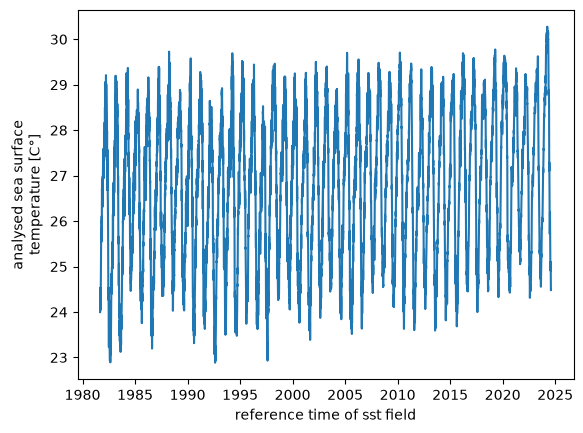

In [15]:
data.sst.mean(['lon','lat']).plot()

### Distribution
The SST is distributed over three coordinates (lat,lon,time).

With a simple .plot(), we get the 1D temperature distribution, combining the three coordinates (so counting each spatial cell, at each time)

(array([3.8150000e+03, 1.7769600e+05, 3.5926340e+06, 1.0159698e+07,
        1.5927181e+07, 2.0231056e+07, 6.2024050e+06, 2.1428000e+04,
        9.7000000e+01, 2.9000000e+01]),
 array([17.74999428, 19.63999367, 21.52999306, 23.41999054, 25.30998993,
        27.19998932, 29.08998871, 30.9799881 , 32.86998749, 34.75998688,
        36.64998627]),
 <BarContainer object of 10 artists>)

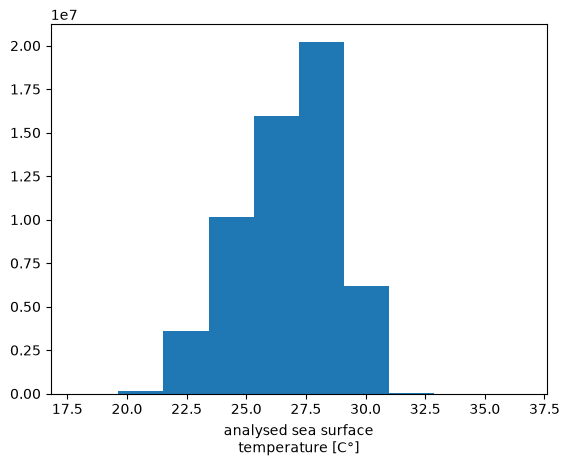

In [16]:
data.sst.plot()

# Fit
We want to compute the annual temperature evolution. We fit a degree-1 polynomial (y = mx+c), a straight line for each individual cell

m is the slope of temperature change as a function of time


Time is given in nanoseconds: datetime64[ns]


<xarray.Dataset> Size: 95kB
Dimensions:               (degree: 2, lat: 64, lon: 92)
Coordinates:
  * degree                (degree) int64 16B 1 0
  * lat                   (lat) float32 256B -6.875 -6.625 ... 8.625 8.875
  * lon                   (lon) float32 368B -7.875 -7.625 ... 14.62 14.88
Data variables:
    polyfit_coefficients  (degree, lat, lon) float64 94kB 6.821e-19 ... nan

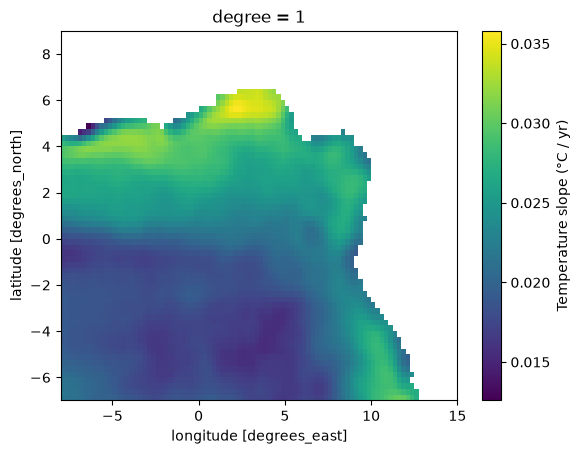

In [17]:
fit =data.sst.polyfit("time", deg=1)
#We select m, stored in 'polyfit_coefficients', giving the temperature variation per year. 
print('Time is given in nanoseconds:', data.sst.time.dtype) 
ns_per_year = 1e9 * 60 * 60 * 24 *365.25 #By default, the parameters are given in C°/nanoseconds, we convert in C°/year
annual_fit = fit.polyfit_coefficients.sel(degree=1) * ns_per_year
annual_fit.plot(cbar_kwargs={'label': 'Temperature slope (°C / yr)'})
fit

### Fit over temperature evolution spatial mean 
Averaging over latitude and longitude, we want to fit a trend on the temperature time series 

- data.time contains the time coordinate, fit contains **m** and **c** of equations **y=mx+c**

- polyval enters each time value **x** in the equation to compute **y**, the temperature variation at that time.

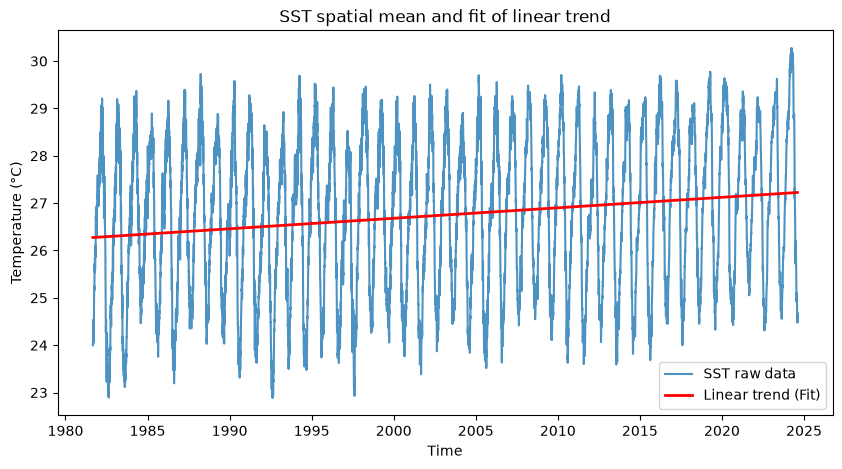

In [19]:
sst_trend = xr.polyval(data.time, fit.polyfit_coefficients)

# Spatial means
sst_spatial = data.sst.mean(dim=['lat', 'lon'])
trend_spatial = sst_trend.mean(dim=['lat', 'lon'])

plt.figure(figsize=(10, 5))
sst_spatial.plot(label='SST raw data', alpha=0.8, color='tab:blue')
trend_spatial.plot(label='Linear trend (Fit)', color='red', linewidth=2)
plt.title('SST spatial mean and fit of linear trend')
plt.ylabel('Temperature (°C)')
plt.xlabel('Time')
plt.legend()
plt.show()



###  Mean yearly change of temperature and total change across the dataset.

In [24]:
annual_fit_avg = float(annual_fit.mean(dim=['lat', 'lon']).values) #Spatial mean

# Computation of the number of elapsed years, as the difference between the first and last date
#We use the pandas.to_datatime function to substract the dates.
time_start = pd.to_datetime(data.time.values[0])
time_end = pd.to_datetime(data.time.values[-1])
total_years = (time_end - time_start)/ pd.Timedelta(days=365.25)


total_change = annual_fit_avg * total_years # We multiply the yearly mean by the number of years to get the total change.
print(f"Mean annual SST variation: {annual_fit_avg:+.4f} °C/ yr")
print(f"Total SST variation over ({total_years:.1f} years): {total_change:+.2f} °C")

Mean annual SST variation: +0.0221 °C/ yr
Total SST variation over (42.9 years): +0.95 °C


## Climatology
We want to compute the evolution of the temperature anomaly, by substracting the seasonal cycles. We will compute:

- Deviation to the global mean

- Deviation to the monthly climatology

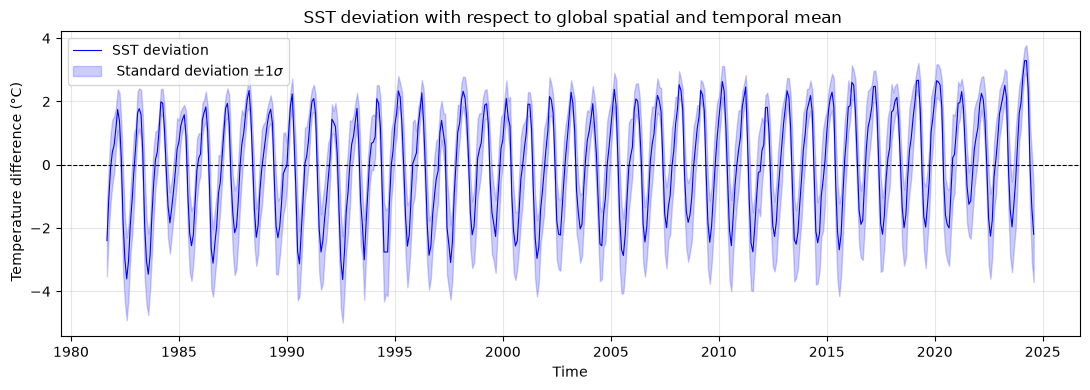

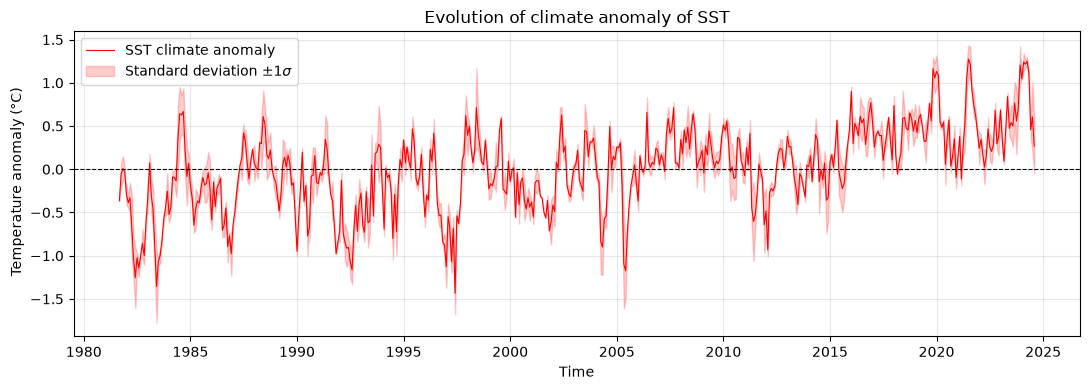

In [25]:
#Monthly mean
sst_monthly = data.sst.resample(time="1MS").mean()

#Spatial mean and standard deviation
sst_spatial_month_mean = sst_monthly.mean(dim=["lat", "lon"])
sst_spatial_month_std = sst_monthly.std(dim=["lat", "lon"])

#Global mean temperature 
global_mean = data.sst.mean(dim=["lat", "lon",'time']).values

#Mean temperature and std for each month (seasonality)
climatology_mean = sst_spatial_month_mean.groupby("time.month").mean(dim="time")
climatology_std = sst_spatial_month_std.groupby("time.month").mean(dim="time")

# Anomaly computation 

#Deviation to global mean 
sst_global_anomaly = sst_spatial_month_mean - global_mean

# SST  Anomaly, removing monthly climatology
sst_clim_anomaly = sst_spatial_month_mean.groupby("time.month") - climatology_mean
std_clim_anomaly = sst_spatial_month_std.groupby("time.month") - climatology_std


# Deviation to global mean
# This plot preservses the seasonal cycle.
plt.figure(figsize=(11, 4))
plt.plot(
    sst_global_anomaly.time,
    sst_global_anomaly,
    color="blue",
    linewidth=0.8,
    label="SST deviation",
)
plt.fill_between(
    sst_global_anomaly.time,
    sst_global_anomaly - sst_spatial_month_std,
    sst_global_anomaly + sst_spatial_month_std,
    alpha=0.2,
    color="blue",
    label=r" Standard deviation $\pm 1 \sigma$",
)
plt.axhline(0, color="k", linestyle="--", linewidth=0.8)
plt.title(" SST deviation with respect to global spatial and temporal mean")
plt.ylabel(" Temperature difference (°C)")
plt.xlabel("Time")
plt.legend(loc="upper left")
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

# SST anomaly compared to monthly mean\
# The seasonal cycle is removed, only keeping occasional climatic events, and long-term trend
plt.figure(figsize=(11, 4))
plt.plot(
    sst_clim_anomaly.time,
    sst_clim_anomaly,
    color="red",
    linewidth=0.8,
    label="SST climate anomaly",
)
plt.fill_between(
    sst_clim_anomaly.time,
    sst_clim_anomaly - std_clim_anomaly,
    sst_clim_anomaly + std_clim_anomaly,
    alpha=0.2,
    color="red",
    label=r"Standard deviation $\pm 1 \sigma$",
)
plt.axhline(0, color="k", linestyle="--", linewidth=0.8)
plt.title("Evolution of climate anomaly of SST")
plt.ylabel(" Temperature anomaly (°C)")
plt.xlabel("Time")
plt.legend(loc="upper left")
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()




# Second dataset 
Mean daily fields from Global Ocean Physics Analysis and Forecast (GLORYS) for January and February 2020, at 1/12° resolution, producted by the Coperinicus Marine Environment Monitoring Service (CMEMS)

- 4 coordinates: time, longitude, latitude, depth
- 6 data variable:  Eastward velocity, northward velocity, potential temperature, salinity, mixed layer thickness, sea surface height

In [27]:
# glorys = xr.open_dataset('Datasets/GG_cmems_concat_jan_fevrier.nc')
# glorys

### Opening multiple files
For this dataset, each file contains one element of the time series 

We can open multiple files using **open_mfdataset()**

In [28]:
glorys = xr.open_mfdataset('Datasets/jan_fev/*')
glorys

<xarray.Dataset> Size: 1GB
Dimensions:    (time: 59, depth: 18, latitude: 157, longitude: 265)
Coordinates:
  * time       (time) datetime64[ns] 472B 2020-01-01 2020-01-02 ... 2020-02-29
  * depth      (depth) float32 72B 0.494 1.541 2.646 3.819 ... 34.43 40.34 47.37
  * latitude   (latitude) float32 628B -6.0 -5.917 -5.833 ... 6.833 6.917 7.0
  * longitude  (longitude) float32 1kB -10.0 -9.917 -9.833 ... 11.83 11.92 12.0
Data variables:
    uo         (time, depth, latitude, longitude) float64 353MB dask.array<chunksize=(1, 18, 157, 265), meta=np.ndarray>
    vo         (time, depth, latitude, longitude) float64 353MB dask.array<chunksize=(1, 18, 157, 265), meta=np.ndarray>
    thetao     (time, depth, latitude, longitude) float64 353MB dask.array<chunksize=(1, 18, 157, 265), meta=np.ndarray>
    so         (time, depth, latitude, longitude) float64 353MB dask.array<chunksize=(1, 18, 157, 265), meta=np.ndarray>
    mlotst     (time, latitude, longitude) float64 20MB dask.array<chunksize=(1, 157, 265), meta=np.ndarray>
    zos        (time, latitude, longitude) float64 20MB dask.array<chunksize=(1, 157, 265), meta=np.ndarray>
Attributes:
    source:                    MERCATOR GLORYS12V1
    institution:               MERCATOR OCEAN
    references:                http://www.mercator-ocean.fr
    history:                   2023/06/01 16:20:05 MERCATOR OCEAN Netcdf crea...
    Conventions:               CF-1.4
    title:                     daily mean fields from Global Ocean Physics An...
    comment:                   CMEMS product
    copernicusmarine_version:  2.0.1

### Saving an xarray
We can create a smaller xarray, which only contains the temperature data variable. The only transmitted attributes are the ones associated with the variable

To save an netCDF file, we use **to_netcdf()**

In [35]:
temp = glorys.thetao 
# We can save a xarray directly to netcdf.
temp.to_netcdf('./Datasets/Temperature_cmems.nc')
temp

<xarray.DataArray 'thetao' (time: 59, depth: 18, latitude: 157, longitude: 265)> Size: 353MB
dask.array<concatenate, shape=(59, 18, 157, 265), dtype=float64, chunksize=(1, 18, 157, 265), chunktype=numpy.ndarray>
Coordinates:
  * time       (time) datetime64[ns] 472B 2020-01-01 2020-01-02 ... 2020-02-29
  * depth      (depth) float32 72B 0.494 1.541 2.646 3.819 ... 34.43 40.34 47.37
  * latitude   (latitude) float32 628B -6.0 -5.917 -5.833 ... 6.833 6.917 7.0
  * longitude  (longitude) float32 1kB -10.0 -9.917 -9.833 ... 11.83 11.92 12.0
Attributes:
    long_name:      Temperature
    valid_min:      -32766
    unit_long:      Degrees Celsius
    units:          degrees_C
    standard_name:  sea_water_potential_temperature
    valid_max:      21306

### Temperture plot with a new coordinate
Now that there is a depth coordinate, we have to chose a layer. 
Here layer 0, the closer to the surface

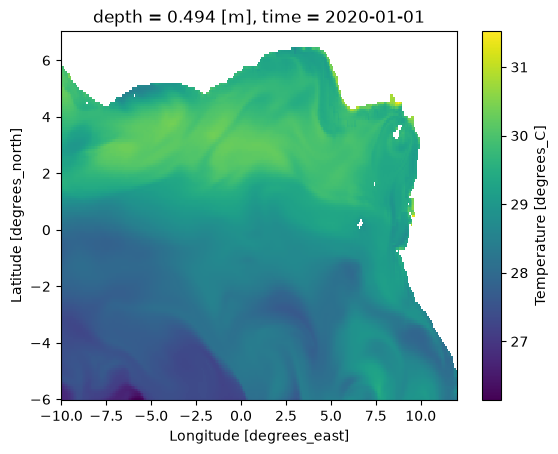

In [36]:
temp.sel(time='2020-01-01').isel(depth=0).plot()

### Time series comparison
We want to investigate how temperature changes with time at different depth.

- We chose a lat/lon point, and a list of depth

- hue = 'depth' indicates we want a plot by depth. By default, there is only the time coordinate left for the x-axis.

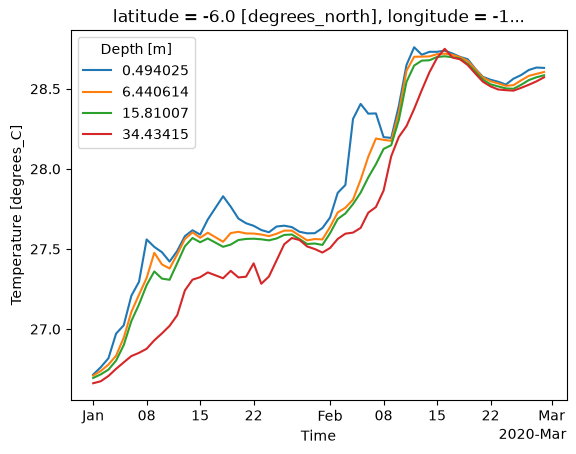

In [37]:
temp.isel(longitude=0, latitude=0, depth=[0, 5, 10,15]).plot(hue='depth')

### Maps comparison
In a similar manner, we can compare maps at three different times, averaged over the depth

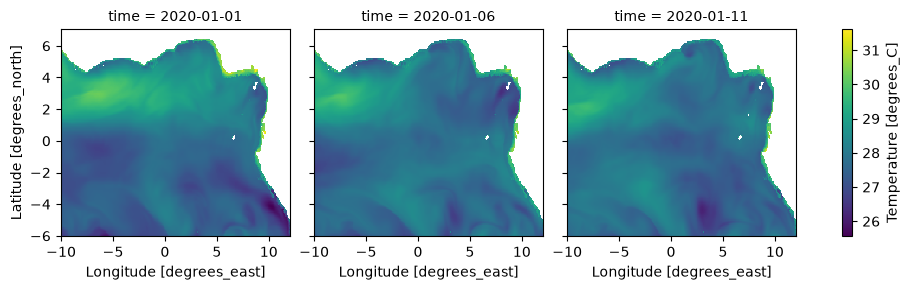

In [38]:
temp.mean('depth').isel(time=[0, 5, 10]).plot(col='time')

### Contour plots
Same plot as above, but we trace contours grouping temperatures in 20 levels.

**contourf()** fills the inside of contours.

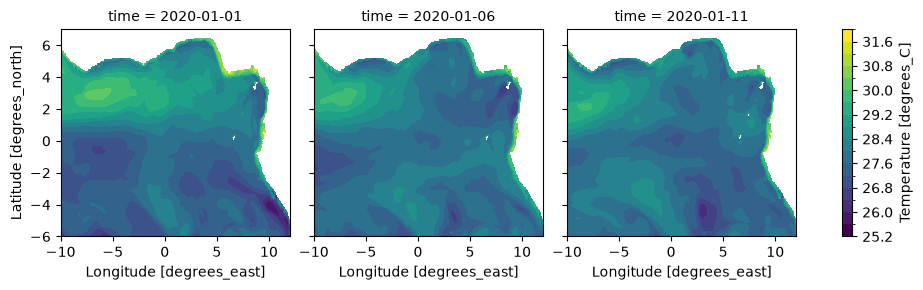

In [39]:
temp.mean('depth').isel(time=[0, 5, 10]).plot.contourf(col='time',levels=20)

By using **contour()** instead of **contourf()**, we only plot the unfilled contours!

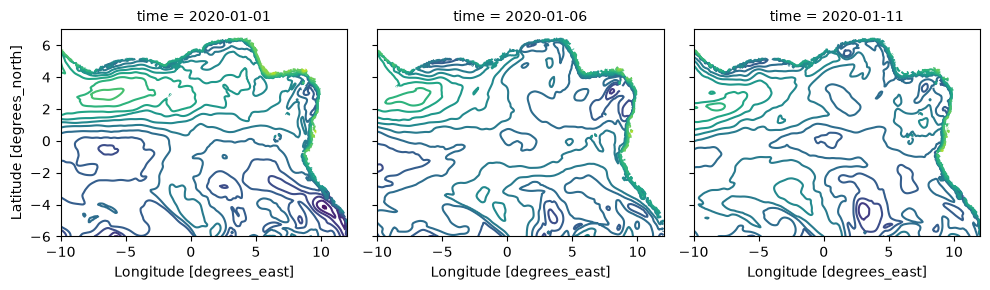

In [34]:
temp.mean('depth').isel(time=[0, 5, 10]).plot.contour(col='time',levels=20)

### Resolution change
We can decrease the resolution with **coarsen()**. Here, we take the mean of 5x5 cell groups.

boundary = pad handles the case where the total of cells in the box is not divisible by 5, by inserting NaNs to complete it.

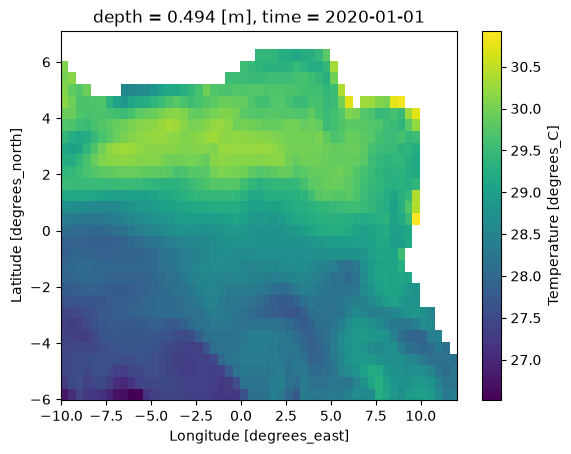

In [40]:
coarse_temp= temp.coarsen(longitude=5, latitude=5,boundary='pad').mean()
coarse_temp.sel(time='2020-01-01').isel(depth=0).plot()

# Plotting on the globe
We can plot the region of study on the globe thanks to our lat/lon coordinates.

### Orthographic projection

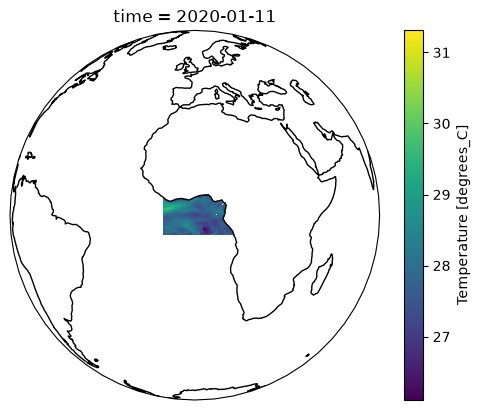

In [46]:
plt.figure
ax = plt.axes(projection=ccrs.Orthographic(0,0))
ax.set_global()
# We take a given snapshot, averaged over depth, for the example. 
temp_dummy = temp.isel(time=10).mean('depth')
temp_dummy.plot(ax=ax, transform=ccrs.PlateCarree())
ax.coastlines()


### Robinson projection

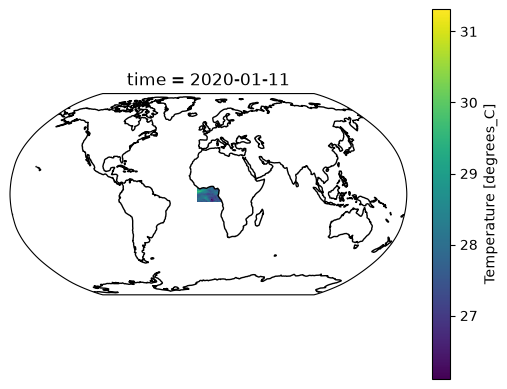

In [42]:
plt.figure
ax = plt.axes(projection=ccrs.Robinson())
ax.set_global()
temp_dummy = temp.isel(time=10).mean('depth')
temp_dummy.plot(ax=ax, transform=ccrs.PlateCarree())
ax.coastlines()

# Comparaison  of the two datasets 
Let's do a quick comparison of the spatial means of the NOAA and GLORYS datasets

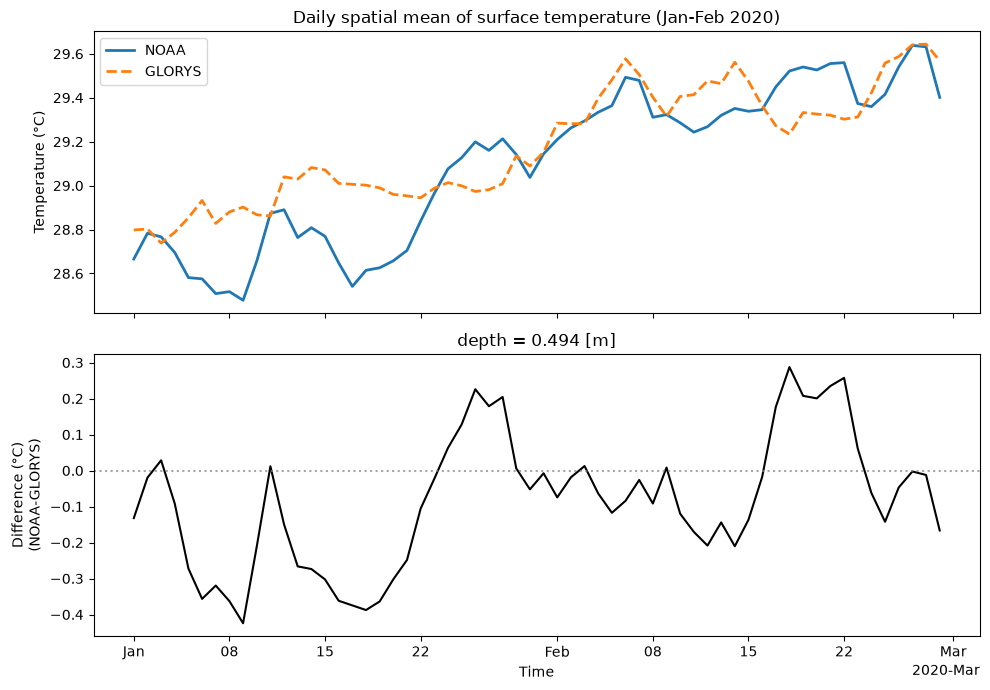

In [43]:
# Select a subset of  the NOAA dataset corresponding to the GLORYS timespan
sst_janfeb = data.sst.sel(time=slice('2020-01-01', '2020-02-29'))
# And taking the layer which is the closer from the surface of GLORYS dataset. 
temp0 = temp.isel(depth=0)

# Computing spatial mean for both
sst_spatial_mean = sst_janfeb.mean(dim=['lat', 'lon'])
temp0_spatial_mean = temp0.mean(dim=['latitude', 'longitude'])
# Difference between the two datasets.
diff = sst_spatial_mean - temp0_spatial_mean 

# And plotting on the same figure.
fig, (ax1, ax2) = plt.subplots(2, 1, figsize=(10, 7), sharex=True)
# Top plot, comparing the datasets 
sst_spatial_mean.plot(ax=ax1, label='NOAA', linewidth=2)
temp0_spatial_mean.plot(ax=ax1, label='GLORYS', linestyle='--', linewidth=2)
                     
ax1.set_title('Daily spatial mean of surface temperature (Jan-Feb 2020)')
ax1.set_ylabel('Temperature (°C)')
ax1.set_xlabel('')  # Hide top X-axis label
ax1.legend()

# Bottom Subplot: Difference Curve
diff.plot(ax=ax2, color='black', linewidth=1.5)
ax2.axhline(0, color='grey', linestyle=':', alpha=0.7)  # Zero reference line
ax2.set_ylabel('Difference (°C)\n(NOAA-GLORYS)')
ax2.set_xlabel('Time')
plt.tight_layout()
plt.show()

# A few last plots

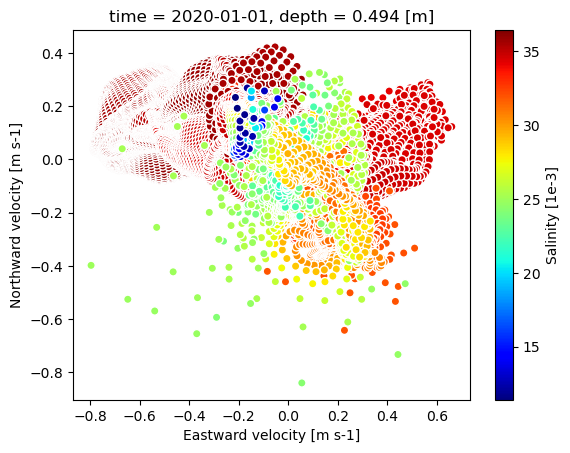

In [48]:
# The position on the figure gives the horizontal velocity, and the color gives salinity.
# The plot shows the coherent behavior of currents. The cells whose current point in a given direction have similar salinities
glorys.isel(time=0, depth=0).plot.scatter(x='uo', y='vo',hue='so',cmap='jet')

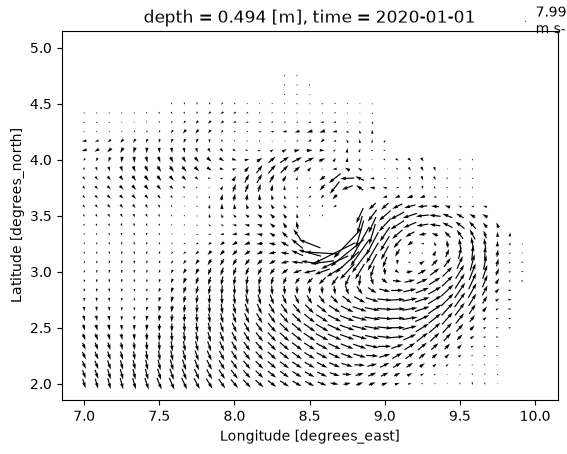

In [44]:
#Horizontal surface curents with the quiver() function, for a portion of lon/lat. 
glorys.isel(time=0, depth=0).sel(latitude=slice(2,5),longitude=slice(7,10)).plot.quiver(x='longitude', y='latitude',u='uo',v='vo')                            

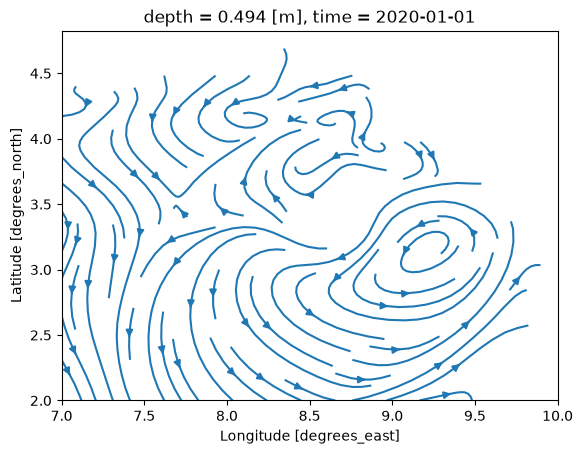

In [45]:
#streamplot() shows the current lines
glorys.isel(time=0, depth=0).sel(latitude=slice(2,5),longitude=slice(7,10)).plot.streamplot(x='longitude', y='latitude',u='uo',v='vo')